In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'Project_Algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

#Restricts the timesteps of the data from timesteps0 to 140
data=data.isel(time=np.arange(1,140+1))
parcel=parcel.isel(time=np.arange(1,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh
    
def grid_location(x,y,z): #faster
    #finding xf and yf
    ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
    xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
    dy=np.round(dy);dx=np.round(dx)

    #digitizing
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
    if which_zh.ndim==0:
        which_zh=np.array([which_zh])
    which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
    which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

    #fixing boundaries
    which_zh[np.where(which_zh==len(data['zh']))]-=1
    which_yh[np.where(which_yh==len(data['yh']))]-=1
    which_xh[np.where(which_xh==len(data['xh']))]-=1
    return which_zh,which_yh,which_xh
    
x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)


which_t = np.ndarray((which_z.shape[0], which_z.shape[1]))
for i in range(which_z.shape[0]):
    which_t[i, :] = i
which_t=which_t.copy().astype(int)

In [ ]:
#######################################################################################################################################
#Calling Data and Plotting Next

In [30]:
# #Job Array

# num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***

# job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
# if job_id==0: job_id=1
# num_parcels=len(data['time']) #total number of parcels
# job_range = num_parcels//num_jobs #number of parcels per job 

# # Calculate start and end based on job_id
# start_job = (job_id - 1) * job_range
# end_job = start_job + job_range
# if job_id==num_jobs: end_job=num_parcels-1
# print(f'running for parcels {start_job}-{end_job-1}')

# data=data.isel(time=slice(start_job,end_job))
# parcel=parcel.isel(time=slice(start_job,end_job))

# x=parcel['x'];y=parcel['y'];z=parcel['z']
# which_z,which_y,which_x=grid_location(x,y,z)

# which_t = np.ndarray((which_z.shape[0], which_z.shape[1]))
# for i in range(which_z.shape[0]):
#     which_t[i, :] = i
# which_t=which_t.copy().astype(int)

In [6]:
#All Parcels Lagrangian Parcels Profile (OPTIMIZED)

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    
    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][:]
        
    print('done loading')
    emptylike=True

label=1

types=['general','cloudy']
vars=['w','qv','qc','qi','th','th_e','buoyancy']
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    
    w_thresh1=0.1
    w_thresh2=0.5
    qcqi_thresh=1e-6
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        if var=='qv':
            lagrangian_var=qv_data[position]
        if var=='qc':
            lagrangian_var=qc_plus_qi[position] #data stored for qc is actually qc+qi
        if var=='qi':
            lagrangian_var=qi_data[position]
        if var=='th':
            lagrangian_var=th_data[position]
        if var=='th_e':
            lagrangian_var=theta_e_data[position]
        if var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh1)]
            masked_z=which_z.flatten()[np.where(lagrangian_w>=w_thresh1)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh2)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=which_z.flatten()[np.where((lagrangian_w>=w_thresh2)&(lagrangian_qcplusqi>=qcqi_thresh))]
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='general':
        output_file=dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{label}.h5'
    if type=='cloudy':
        output_file=dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{label}.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_th_e', data=profile_th_e, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type general
variable w
variable qv
variable qc
variable qi
variable th
variable th_e
variable buoyancy
done
type cloudy
variable w
variable qv
variable qc
variable qi
variable th
variable th_e
variable buoyancy
done


In [1]:
# #All Parcels Lagrangian Parcels Profile (OPTIMIZED) (CTRL)

# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     variable='th'; th_data=data[variable].data # get qc data
#     variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
#     print('done loading')
#     emptylike=True


# types=['general','cloudy']
# vars=['w','qv','qc','qi','th','buoyancy']
# for type in types:
#     print(f"type {type}")

#     global w_thresh
#     # #creates profile storage and adds z column  
#     w_thresh=1 #m/s
#     qcqi_thresh=1e-6 #kg/kg
    
#     #create profile array
#     for var in vars:
#         zhs=data['zh'].values
#         globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#         globals()[f"profile_{var}"][:,2]=zhs

#     position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
#     lagrangian_w=w_data[position]
#     lagrangian_qcplusqi=qc_plus_qi[position]
    
#     for var in vars:
#         print(f"variable {var}")
#         if var=='w':
#             lagrangian_var=w_data[position]
#         if var=='qv':
#             lagrangian_var=qv_data[position]
#         if var=='qc':
#             lagrangian_var=qc_plus_qi[position] #data stored for qc is actually qc+qi
#         if var=='qi':
#             lagrangian_var=qi_data[position]
#         if var=='th':
#             lagrangian_var=th_data[position]
#         if var=='buoyancy':
#             lagrangian_var=buoyancy_data[position]

              
#         #if w_zdata greater than threshold, add to profile z column and add count
#         if type=='general':
#             masked_var=lagrangian_var[np.where(lagrangian_w<w_thresh)]
#             masked_z=which_z.flatten()[np.where(lagrangian_w<w_thresh)]
#         elif type=='cloudy':
#             masked_var=lagrangian_var[np.where((lagrangian_w<w_thresh)|(lagrangian_qcplusqi<qcqi_thresh))]
#             masked_z=which_z.flatten()[np.where((lagrangian_w<w_thresh)|(lagrangian_qcplusqi<qcqi_thresh))]
            
#         for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
#             # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
#             globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
#             globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
#     if type=='general':
#         output_file=dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{label}.h5'
#     if type=='cloudy':
#         output_file=dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{label}.h5'
#     import h5py
#     with h5py.File(output_file, 'w') as f:
#         f.create_dataset('profile_w', data=profile_w, compression="gzip")
#         f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
#         f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
#         f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
#         f.create_dataset('profile_th', data=profile_th, compression="gzip")
#         f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
#     print('done')

In [21]:
##################
# Plotting

In [4]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

currently on type general
currently on type cloudy


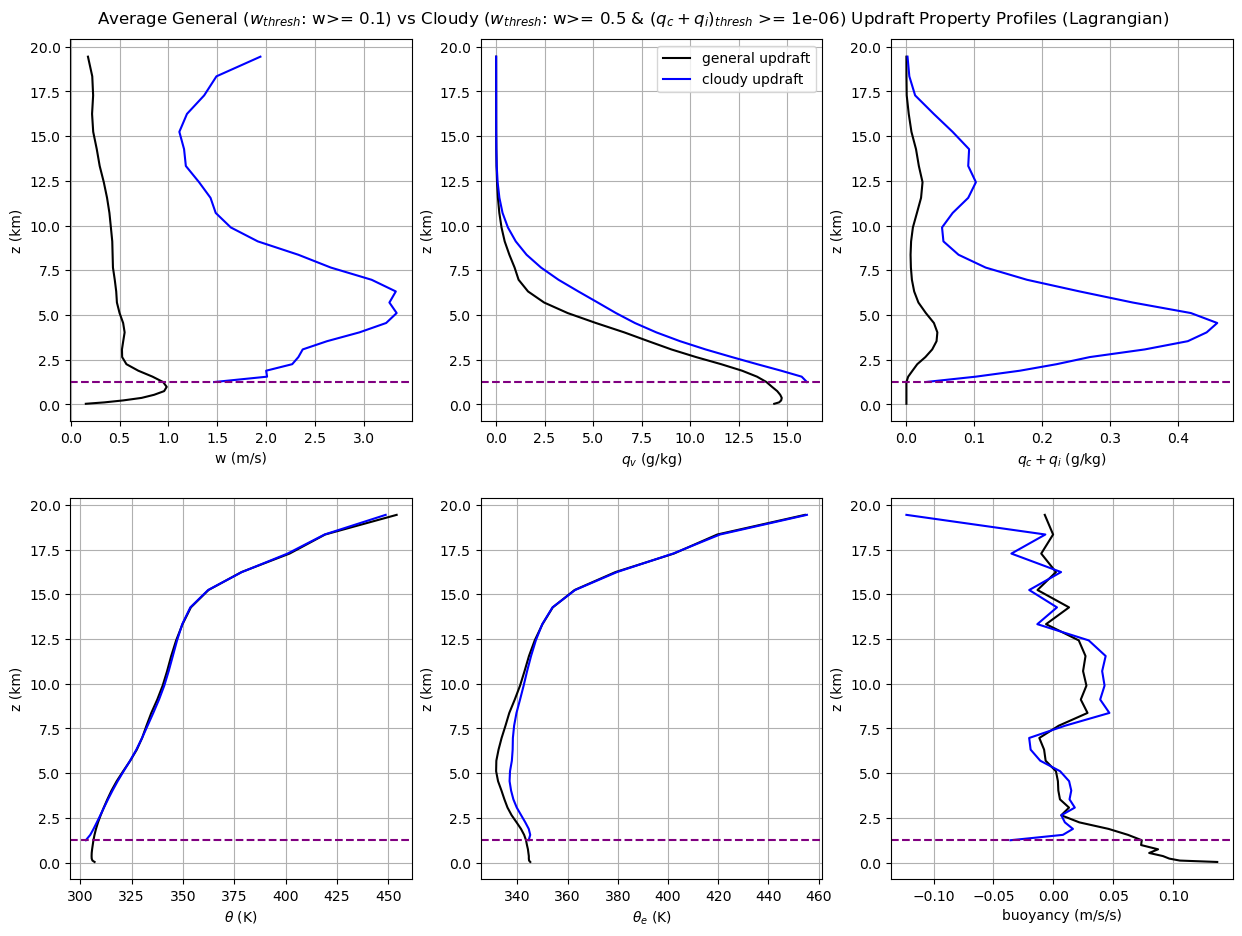

In [5]:
#Plotting (for all variables)
import h5py

# Produced averaged profiles for plotting
def averaged_profiles(var):
    profile = globals()[f"profile_{var}"]
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

####################################################################
res = '1km'
# res = '250m'
label=1

# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles (Lagrangian)")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
fig.subplots_adjust(top=0.95)
####################################################################
for type in ["general", "cloudy"]:
    print(f'currently on type {type}')

    if res=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{label}.h5'
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{label}.h5' 
    
    if res=='250m':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_lagrangian_profiles_wthresh{label}.h5' 
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_wthresh{label}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_th_e = np.array(f['profile_th_e'])
        profile_buoyancy = np.array(f['profile_buoyancy'])
            
    #adding qc and qi profile together
    profile_qc[:,0]+=profile_qi[:,0] 
    profile_qc[:,1]+=profile_qi[:,1] 

    for var in ['qv','qc']:
        globals()[f"profile_{var}"][:,0]*=1000
    
    # Plotting function
    def plotting(out_var, axis, label, color):
        axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
        axis.grid(True)
    
    # Uses Averaged_Profiles Function
    vars = ['w', 'qv', 'qc', 'th','th_e','buoyancy']
    # vars = ['w']  # TESTING
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(var)
    
    axises = [ax1, ax2, ax3, ax4, ax5, ax6]
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var, axis, xlabel in zip(vars, axises, xlabels):
        if type == 'general':
            color = 'k'
        elif type == 'cloudy':
            color = 'blue'
        plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color)
        axis.set_ylabel('z (km)')
        axis.set_xlabel(xlabel)
        if axis==ax2:
            axis.legend()  # add legend
############################

#MEAN CLOUD BASE
qcqi_profile=averaged_profiles('qc')
where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
cloudbase=qcqi_profile[where_cloudbase,1]
for axis in axises:
    axis.axhline(cloudbase,color='purple',linestyle='dashed')


#save plot
if res == '1km':
    plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"
elif res == '250m':
    plt.savefig(dir+f'Project_Algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"


In [82]:
# #CTRL Plotting (for all variables)
# import h5py

# # Produced averaged profiles for plotting
# def averaged_profiles(var):
#     profile = globals()[f"profile_{var}"]
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# ####################################################################
# res = '1km'
# # res = '250m'

# # Uses Plotting Function 
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# fig.suptitle(f"Average Lagrangian Non-General vs Non-Cloudy Updraft CTRL Property Profiles")
# ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
# fig.subplots_adjust(top=0.95)
# ####################################################################
# for type in ["general", "cloudy"]:
#     print(f'currently on type {type}')

#     if res=='1km':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{label}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{label}.h5' 
    
#     if res=='250m':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_lagrangian_profiles_CTRL_wthresh{label}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_CTRL_wthresh{label}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])
            
#     #adding qc and qi profile together
#     profile_qc[:,0]+=profile_qi[:,0] 
#     profile_qc[:,1]+=profile_qi[:,1] 

#     for var in ['qv','qc']:
#         globals()[f"profile_{var}"][:,0]*=1000
    
#     # Plotting function
#     def plotting(out_var, axis, label, color):
#         axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
#         axis.grid(True)
    
#     # Uses Averaged_Profiles Function
#     vars = ['w', 'qv', 'qc', 'th','buoyancy']
#     # vars = ['w']  # TESTING
#     for var in vars:
#         globals()[f"out_{var}"] = averaged_profiles(var)
    
#     axises = [ax1, ax2, ax3, ax4, ax5]
#     xlabels = ['w (m/s)', 'qv (g/kg)', 'qc + qi (g/kg)', 'th (K)', 'buoyancy (m/s/s)']
#     for var, axis, xlabel in zip(vars, axises, xlabels):
#         if type == 'general':
#             color = 'k'
#         elif type == 'cloudy':
#             color = 'blue'
#         plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color)
#         axis.set_ylabel('z (km)')
#         axis.set_xlabel(xlabel)
#         if axis==ax2:
#             axis.legend()  # add legend
# ############################

# #save plot
# if res == '1km':
#     plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_CTRL_wthresh{label}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"
# elif res == '250m':
#     plt.savefig(dir+f'Project_Algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_CTRL_wthresh{label}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"


currently on type general
currently on type cloudy


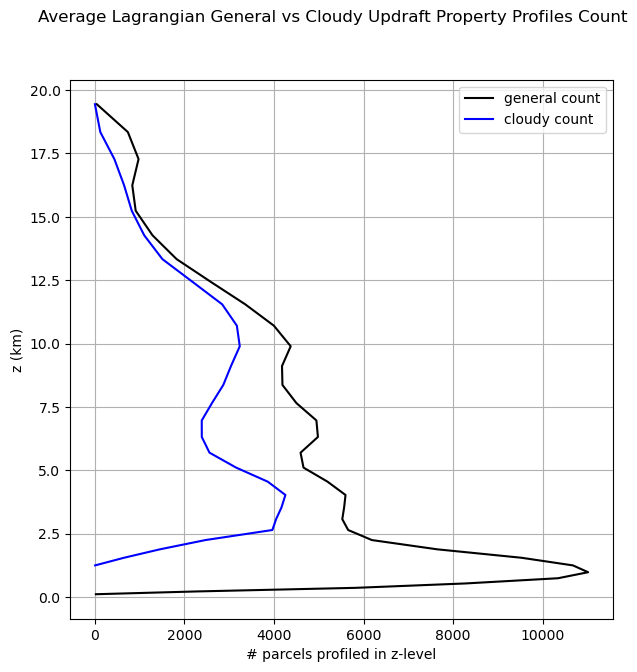

In [13]:
# #Plotting counter column
# res='1km'
# # res='250m'

# #Uses CounterPlotting Function
# fig, axs = plt.subplots(1,1, figsize=(7,7))
# fig.suptitle(f"Average Lagrangian General vs Cloudy Updraft Property Profiles Count")
# # fig.suptitle(f"average lagrangian cloudy updraft property profiles") #uncomment if "cloudy updrafts"
# # ax1 = axs.flatten()
# # plt.tight_layout()
# types=["general","cloudy"]
# for type in types:
#     print(f'currently on type {type}')

#     if res=='1km':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{label}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{label}.h5' 
    
#     if res=='250m':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_lagrangian_profiles_wthresh{label}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_wthresh{label}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])



#     def counter_plotting(out_var,axis,label,color):
#         out_var=out_var[ (out_var[:, 1] != 0)];
#         axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
#         axis.grid(True)

#         # print(np.sum(out_var[:,1])) #TESTING
    
#     vars=['w']
#     axises=[axs]
#     xlabels=['# parcels profiled in z-level']
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'
#         counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.legend();
#     ############################# 
#     #save plot
#     dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     if res=='1km':
#         plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_counter_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 
#     if res=='250m':
#         plt.savefig(dir+f'Project_Algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_counter_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 

In [9]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

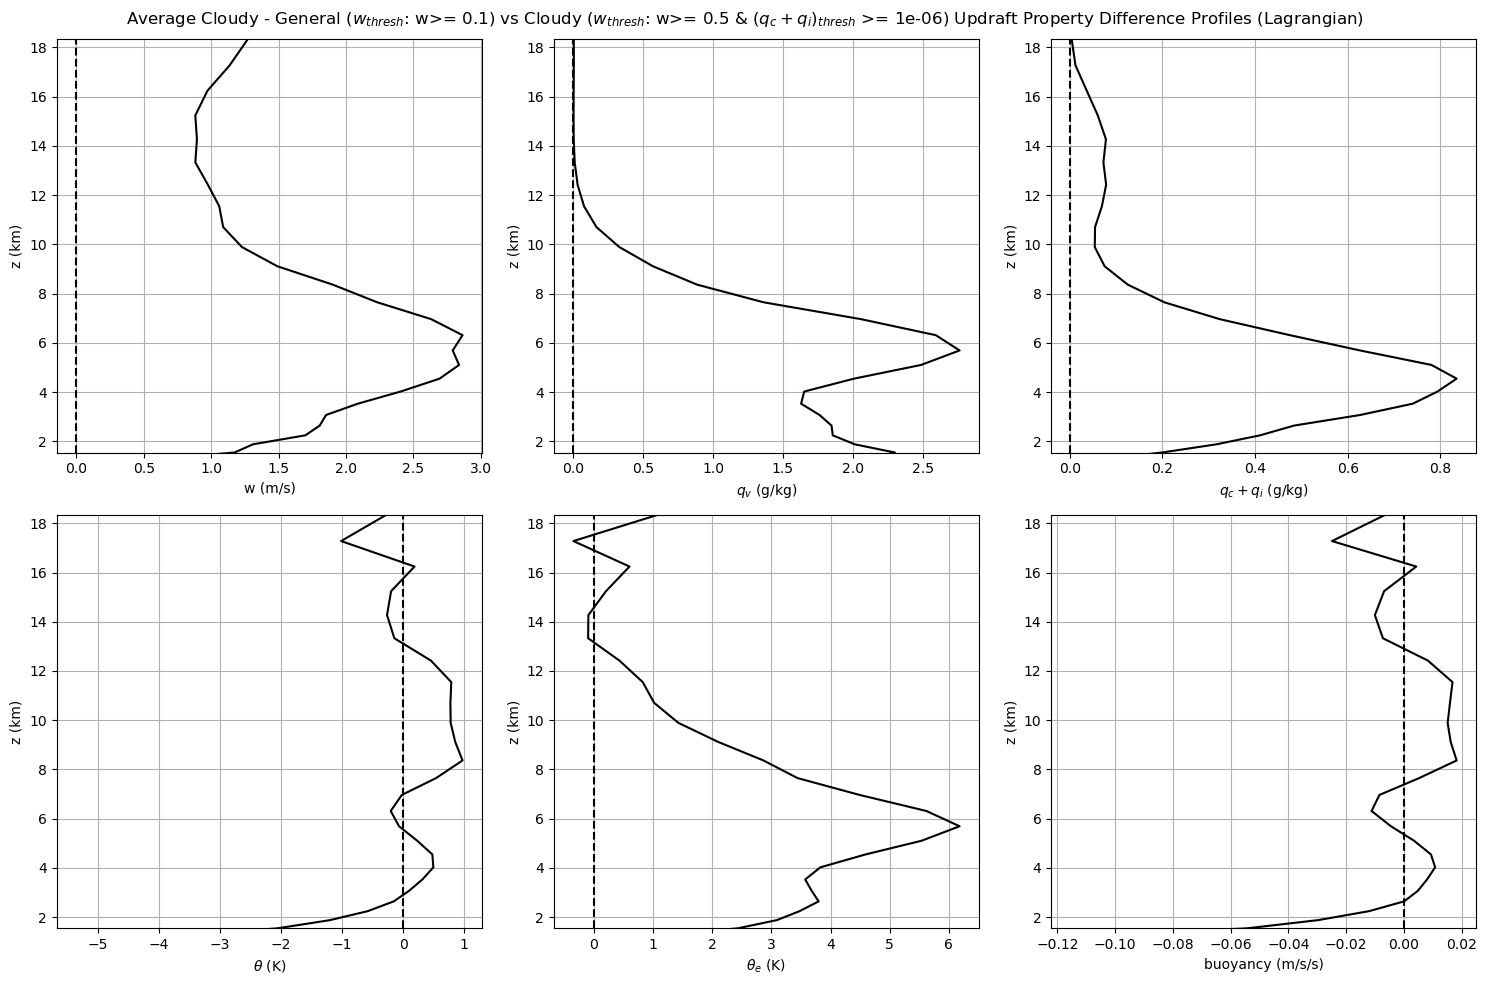

In [10]:
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

res='1km'
def get_data(type):
    if res=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{label}.h5'
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{label}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])


    
def diff_plotting():
    #setting up figure
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles (Lagrangian)")
    ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

    #the plotting
    vars=['w','qv','qc','th','th_e','buoyancy']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        if var=='qv':axis=ax2
        if var=='qc':axis=ax3
        if var=='th':axis=ax4
        if var=='th_e':axis=ax5
        if var=='buoyancy':axis=ax6

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
  
        #averaging
        out_var_diff=average_difference(out_var_one,out_var_two)

        #(kg/kg) ==> (g/kg)
        if var=='qv' or var=='qc':
            out_var_diff[:,0]*=1000
            
        axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
        axis.axvline(0,color='k',linestyle='dashed')
        # axis.set_ylim(bottom=0,top=20)
        axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        
    plt.tight_layout()

# #MEAN CLOUD BASE
# for axis in axises:
#     axis.axhline(cloudbase,color='purple',linestyle='dashed')
    plt.savefig(dir+f'Project_Algorithms/plots/1km_lagrangian_updraft_profiles_diff_wthresh{label}.jpg', bbox_inches='tight', dpi=300) #save plot
diff_plotting() 